
Final Q-table:
[[0.444  0.9465 0.6366 0.2322]
 [0.6944 0.     0.0043 0.7415]
 [0.0045 0.7886 0.3918 0.6369]
 [0.5469 0.     0.4569 0.0547]
 [0.4075 0.9568 0.     0.3739]
 [0.     0.     0.     0.    ]
 [0.     0.8817 0.     0.8625]
 [0.     0.     0.     0.    ]
 [0.2703 0.     0.9682 0.4054]
 [0.553  0.7874 0.9795 0.    ]
 [0.7521 0.9897 0.     0.9184]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.8309 0.9876 0.9461]
 [0.9738 0.99   1.     0.9754]
 [0.     0.     0.     0.    ]]

Estimated State-Value Function:
[0.9465 0.7415 0.7886 0.5469 0.9568 0.     0.8817 0.     0.9682 0.9795
 0.9897 0.     0.     0.9876 1.     0.    ]

Learned Policy:
State 0: ↓
State 1: ↑
State 2: ↓
State 3: ←
State 4: ↓
State 5: ←
State 6: ↓
State 7: ←
State 8: →
State 9: →
State 10: ↓
State 11: ←
State 12: ←
State 13: →
State 14: →
State 15: ←

Average reward over last 1000 episodes: 0.953


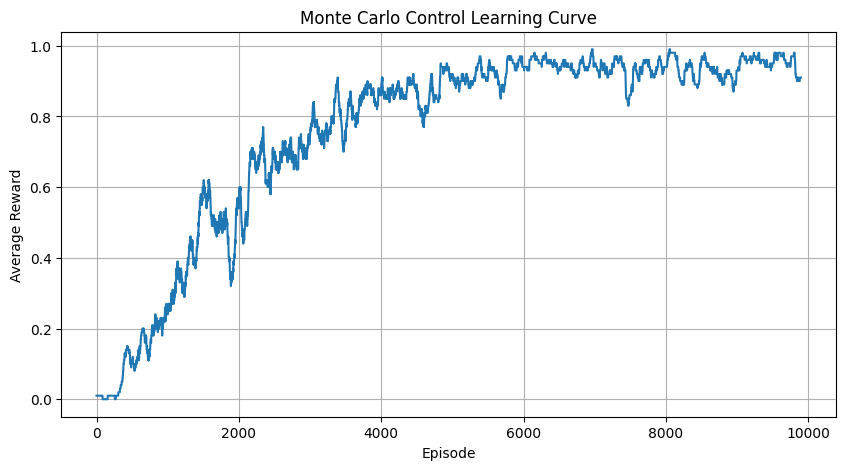

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# Environment details
num_states = env.observation_space.n
num_actions = env.action_space.n

# Parameters
num_episodes = 10000
alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

# Initialize Q-table
Q = np.zeros((num_states, num_actions))

# Store rewards
episode_rewards = []


# Epsilon-greedy action selection
def choose_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()

    else:
        # Exploitation
        return np.argmax(Q[state])


# Monte Carlo Control
for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Store episode
    episode_data = []

    done = False

    # Generate complete episode
    while not done:

        # Select action
        action = choose_action(state, epsilon)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Store state, action and reward
        episode_data.append(
            (state, action, reward)
        )

        # Move to next state
        state = next_state

        # Check termination
        done = terminated or truncated


    # Calculate return
    G = 0

    # Process episode backwards
    for state, action, reward in reversed(episode_data):

        G = reward + gamma * G

        # Monte Carlo Q-value update
        Q[state, action] = Q[state, action] + alpha * (
            G - Q[state, action]
        )


    # Store total reward
    total_reward = sum(
        x[2] for x in episode_data
    )

    episode_rewards.append(total_reward)


    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# Estimated State-Value Function
V = np.max(Q, axis=1)


# Learned Policy
policy = np.argmax(Q, axis=1)


# Display Final Q-table
print("\nFinal Q-table:")
print(np.round(Q, 4))


# Display State-Value Function
print("\nEstimated State-Value Function:")
print(np.round(V, 4))


# Action symbols
action_symbols = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}


# Display Learned Policy
print("\nLearned Policy:")

for state in range(num_states):

    print(
        f"State {state}: "
        f"{action_symbols[policy[state]]}"
    )


# Average reward over last 1000 episodes
average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    round(average_reward, 4)
)


# Learning Curve
window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)


plt.figure(figsize=(10, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "Monte Carlo Control Learning Curve"
)

plt.grid()

plt.show()


# Close environment
env.close()

